# 📈 Pairs Trading — Empirical Methods in Finance
---
**Project 1** | Hotel Industry Stocks | 2010–2025

> **Objective:** Identify cointegrated pairs of stocks in the hotel sector and exploit the mean-reverting behaviour of their spread for a pairs trading strategy.

---

## 📥 Step 1 — Download Data of Interest

We will use data downloaded from **yfinance**. The data we download is from the **Hotel industry**. We download 5 different stocks for this project:

| Ticker | Company |
|--------|---------|
| `BKNG` | Booking Holdings |
| `H` | Hyatt Hotels |
| `HLT` | Hilton Worldwide |
| `MAR` | Marriott International |
| `IHG` | InterContinental Hotels Group |

In [ ]:
# --- Imports ---
from data_and_trading_utils import Fetch_Data
from data_and_trading_utils import Select_Pair
from data_and_trading_utils import Fetch_wrds
from data_and_trading_utils import Simple_Pair_Trading
from data_and_trading_utils import Rolling_Pair_Trading
from data_and_trading_utils import Rolling_Pair_Trading_coint_filter
import matplotlib.pyplot as plt
import numpy as np
from utils import plot_n_series, plot_wealth_positions_spread
import pandas as pd


In [2]:
start_date = '2010-01-01'
end_date = '2025-01-01'
tickers = ['IHG', 'HLT', 'MAR', 'BKNG', 'H']

In [3]:
# --- Download & log-transform prices ---
fetcher = Fetch_Data(start_date, end_date, tickers)
data_raw   = fetcher.download_data()

/Users/mpecaut/Empirical-Methods-In-Finance/Project1/main.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.data = yf.download(self.tickers, start = self.start_date, end = self.end_date)
[*********************100%***********************]  5 of 5 completed


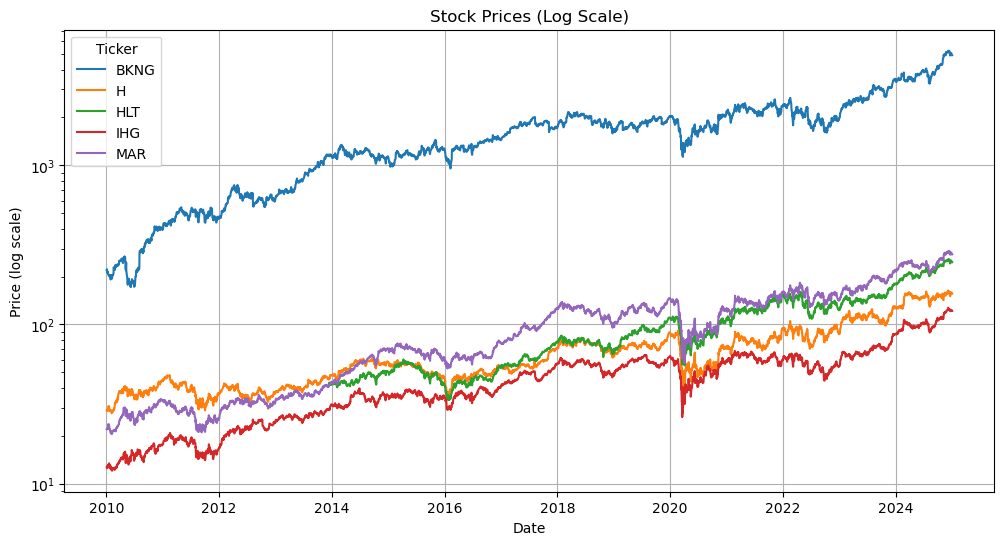

In [5]:
plot_n_series(data_raw,'Stock Prices (Log Scale)','log', 'Date', 'Price (log scale)')

---
## 📊 Step 2 — Stationarity & Cointegration

**Stationarity** means that a serie's two first moments are constant through time along with time-independent autocovariance (covariance of a time series with itself only depends on the lag). This implies that the series does not exhibit any trend or seasonal effect ; it constantly reverts to its mean.

---

It is important to differentiate **cointegration** from **correlation**. Two assets are correlated in the sense that if one moves up, the other will certainly also move up by some amount. Mathematically speaking, correlation measures the short-term linear relationship between two time series. However, this might not imply that the spread between those 2 assets is constant. Indeed, it might even diverge. This is where cointegration comes into play. If two assets are cointegrated, then the spread (the price difference between the 2 assets) will remain constant through time (spread is therefore stationary). This implies that if the spread diverges (goes above or below its normal level), in theory, it should not be long before this value comes back to its average level. This is what we will exploit later on.

For some little more theory, cointegration describes the long-term relationship between two non-stationary time series. While the individual serie might drift (non-stationarity condition), a specific linear combination of them stays near a constant mean.

---

#### 🔬 What does `statsmodels.tsa.stattools.coint` do?

**Step 1 — Regress the two time series.**  
For example, if the first time series is Booking log price and the second one is IHG log price:

$$Booking_t = \alpha + \beta \cdot IHG_t + \epsilon_t$$

| Parameter | Interpretation |
|-----------|---------------|
| $\alpha$ | Price level difference between the two stocks. Since Booking trades at log price ≈ 6–8 and IHG ≈ 2.5–5.5, we expect $\alpha \approx 3$ |
| $\beta$ | How much of Booking's price is explained by IHG — analogous to the CAPM beta. If $\beta = 0.3$, a 1% drop in IHG implies a 0.3% drop in Booking |
| $\epsilon$ | The residual — the part of Booking's price *unexplained* by IHG, capturing the random deviation from the long-run relationship |

**Step 2 — Extract the residuals** and test them for stationarity using an ADF test. If the residuals are stationary, the pair is cointegrated.

In [6]:
data = np.log(data_raw)

In [7]:
# --- Run cointegration test on all permutations ---
pairselect = Select_Pair(data)
permut     = pairselect.permutations()
most_coint_pair, data_most_coint_pair = pairselect.are_cointegrated()

 Most cointegrated pair: BKNG — IHG


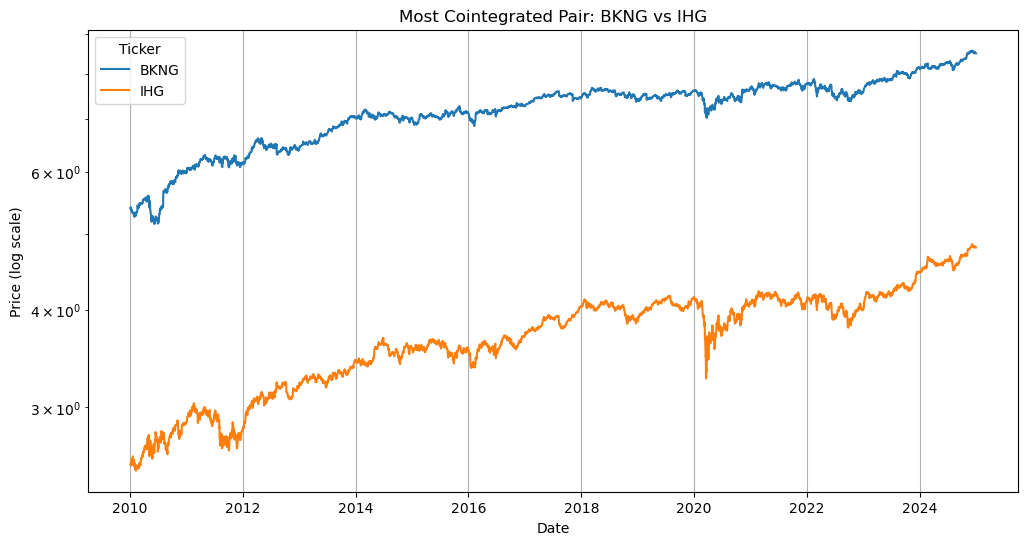

In [8]:
# --- Plot the most cointegrated pair ---
print(f' Most cointegrated pair: {most_coint_pair[0]} — {most_coint_pair[1]}')
plot_n_series(data_most_coint_pair, f'Most Cointegrated Pair: {most_coint_pair[0]} vs {most_coint_pair[1]}', 'log', 'Date', 'Price (log scale)')

### Extract the values alpha,beta and the spread

In [9]:
tickers = [data_most_coint_pair.columns[0],data_most_coint_pair.columns[1]]

alpha,beta,residuals = pairselect.extract_ratios_cointegrated_pair(data_most_coint_pair,tickers)


In [10]:
std_residuals = pairselect.normalize_residuals(residuals)


---

## 📈 Step 3 — Pair Trading


Now that we have our pair and we have been able to extract its residual and standardize it, we'll implement a first, simple trading strat based on mean reversion of the spread.

Our regression looks like : $$booking_t = \alpha + \beta IHG_t + \epsilon_t$$ therefore, the normalized spread is : $$z_t = \left( (booking_t - \alpha - \beta IHG_t )- \mu (\epsilon_t) \right) / \sigma(\epsilon_t)$$

We will now incorporate the bid-ask spread as well as some transaction costs. What we will do is to also try to find the optimal threshold (the one leading to the highest sharpe ratio) to enter a trade. I will explain that a little bit below but for now, I will go into WRDS database and fetch crsp bid and ask date for BKNG and IHG

In [ ]:
start_date = '2010-01-01'
end_date = '2025-02-01'
tickers = ['IHG','BKNG']
username = 'mariuspecaut'
fetch_wrds = Fetch_wrds(start_date, end_date, tickers, username)
fetch_wrds.create_wrds_connection()
ticker_aliases = {'BKNG': ['BKNG', 'PCLN'],}

bid_ask_spread = fetch_wrds.fetch_bid_ask(ticker_aliases)

In [15]:
fetch_wrds.create_wrds_connection()
ticker_aliases = {'BKNG': ['BKNG', 'PCLN'],}

bid_ask_spread = fetch_wrds.fetch_bid_ask(ticker_aliases)

OperationalError: (psycopg2.OperationalError) connection to server at "wrds-pgdata.wharton.upenn.edu" (165.123.60.118), port 9737 failed: server closed the connection unexpectedly
	This probably means the server terminated abnormally
	before or while processing the request.

(Background on this error at: https://sqlalche.me/e/20/e3q8)

### First, simple trading strat on the whole sample

We have defined the spread as the residual $\varepsilon_t$ which is the part unexplained when regressing asset A on asset B. This spread, which we normalize, should be stationary, it mean-reverts around 0. For visualization purposes, we will test this hypothesis using a Augmented Dickey-Fuller test.

The Null Hypothesis $H_0$ : The time series is not stationary (it has a unique root) ; its mean is not 0. 

In [ ]:
p_val,crit_vals = pairselect.test_stationarity()
pairselect.adf_test_results(p_val)

H0 is rejected : the residuals are stationary


In [ ]:
threshold = 1.5

In [ ]:
simplepairtrading = Simple_Pair_Trading(data_raw,data_most_coint_pair,std_residuals,bid_ask_spread,alpha,beta,threshold)
cumulative_pnl_simple, sharpe_ratio_simple = simplepairtrading.simple_pair_trading()

---
## Step 5 - Rolling window pair trading strategy 

The previous trading strategy was developed using an estimation of beta based on the whole sample. This is problematic as the position size which is opened at time t depends on beta which depends itself on the whole sample. In practice, this is impossible as we never know what will happen in the future. To overcome this, I will use a rolling window to estimate beta, make decisions and then go forward. 

I will use a rolling windows of 252 days (1 year) to first estimate beta. Then, based on this value, I take decision for tomorrow based on today's spread, where the size I invest in each asset depends on the value of current beta.

In [ ]:
window = 252
coint_window = 504

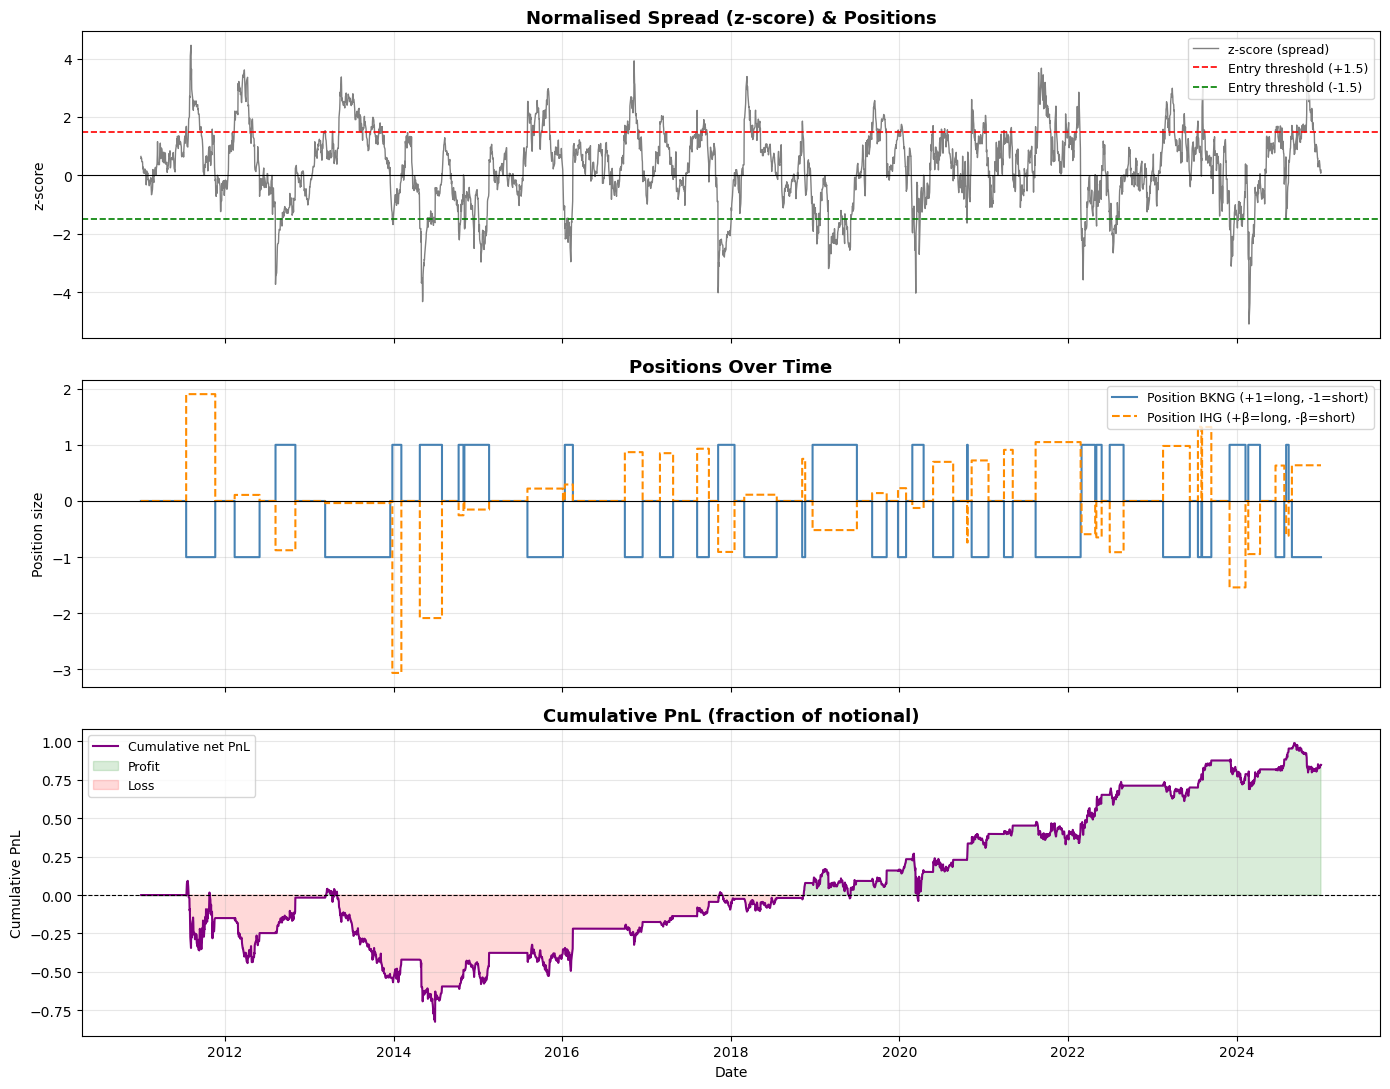

Sharpe ratio (rolling, annualised): 0.0428


In [ ]:
rollingpairtrading = Rolling_Pair_Trading(window, coint_window, data_raw,data_most_coint_pair,bid_ask_spread,threshold = 1.5)
rollingpairtrading.extract_rolling_params()
cumulative_pnl_rolling, sharpe_ratio_rolling = rollingpairtrading.simple_rolling_pair_trading()


---
## Step 6 — Rolling Window Strategy with Engle-Granger Cointegration Filter

The previous rolling strategy assumed the pair **remains cointegrated throughout the entire sample**. This may not hold in practice — structural breaks (e.g. COVID, financial crises) or fundamental business changes can cause the long-run relationship to break down temporarily.

**Key idea:** Before generating any signal on day $t$, test whether the pair was still cointegrated over the **last 252 trading days** using the Engle-Granger test:

$$H_0: \text{the residual } \varepsilon_t \text{ is non-stationary (no cointegration)}$$

| p-value | Decision |
|---|---|
| $p < 0.05$ | Reject $H_0$ → cointegration confirmed → **trade normally** |
| $p \geq 0.05$ | Fail to reject $H_0$ → cointegration uncertain → **close any open position and stay flat** |

This adds a regime filter on top of the z-score signal: we only exploit mean-reversion when the statistical foundation (cointegration) is confirmed by the data.


Cointegrated windows : 816 / 3270 (25.0%) → trading allowed
Non-cointegrated     : 2454 (75.0%) → forced flat


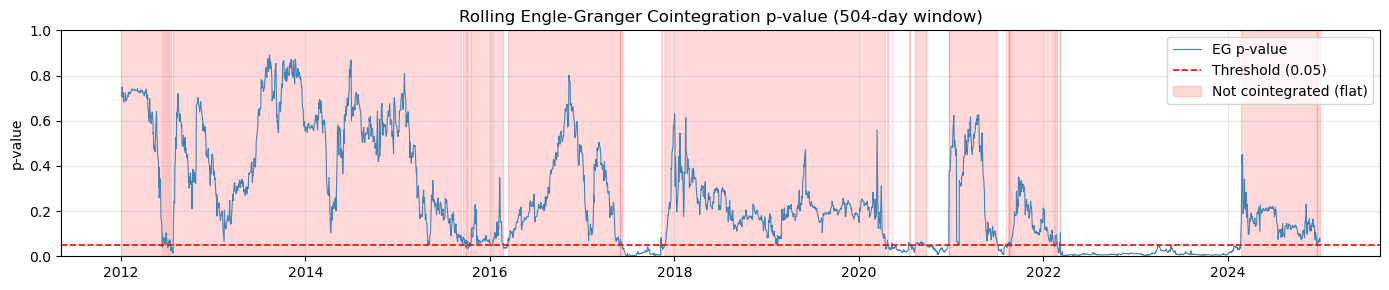

In [ ]:
window = 252
coint_window = 504
rollingcointfilter_pairtrading = Rolling_Pair_Trading_coint_filter(0.05,window,coint_window, data_raw,data_most_coint_pair,bid_ask_spread,threshold = 1.5)

rollingcointfilter_pairtrading.extract_cointegration_filter_params()
cumulative_pnl_rolling_cointfilter, sharpe_ratio_rolling_cointfilter = rollingcointfilter_pairtrading.cointegration_filter_pair_trading()

We can see that rejecting the trading for same cointegration periods leads to overall cumulative returns which are smaller. However, it is clear that the drawdowns are way more limited, reaching approximately $-0.1$, compared to $-0.8$ when allowing to trade regardless of the cointegration regime. This highlights a meaningful risk-adjusted trade-off: filtering trades based on rolling cointegration significantly improves the strategy's resilience to adverse market conditions, even if it comes at the cost of reduced total returns.

---
*End of Project 1*